# CIFAR-10 Classification: CNN from Scratch vs ResNet-18 Transfer Learning

### Complete Pipeline
1. Load local CIFAR-10 dataset (train/, test/, trainLabels.csv)
2. Inspect & visualize the dataset
3. Train/Validation split
4. Build & train CNN from scratch
5. Visualize conv filters & feature map activations
6. Fine-tune ResNet-18 (Transfer Learning)
7. Compare accuracy: Scratch CNN vs Transfer Learning
8. Generate test predictions
9. CNN limitations → motivation for RNNs & Transformers

## Part 1 — Import Libraries

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)

np.random.seed(SEED)
torch.manual_seed(SEED)

print('PyTorch version   :', torch.__version__)
print('Torchvision version:', torchvision.__version__)

PyTorch version   : 2.13.0
Torchvision version: 0.28.0


## Part 2 — Select Device

In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print('Using device:', device)

Using device: mps


## Part 3 — Set Dataset Paths

**Change DATA_DIR if your folder is in a different location.**

In [3]:
DATA_DIR = "Cifar-10"

TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")
LABEL_FILE = os.path.join(DATA_DIR, "trainLabels.csv")

## Part 4 — Verify Files Exist

In [4]:
print('DATA_DIR   exists:', os.path.exists(DATA_DIR))
print('TRAIN_DIR  exists:', os.path.exists(TRAIN_DIR))
print('TEST_DIR   exists:', os.path.exists(TEST_DIR))
print('LABEL_FILE exists:', os.path.exists(LABEL_FILE))
assert os.path.exists(DATA_DIR),   'DATA_DIR not found'
assert os.path.exists(TRAIN_DIR),  'train/ not found'
assert os.path.exists(TEST_DIR),   'test/ not found'
assert os.path.exists(LABEL_FILE), 'trainLabels.csv not found'
print('All paths verified.')

DATA_DIR   exists: True
TRAIN_DIR  exists: True
TEST_DIR   exists: True
LABEL_FILE exists: True
All paths verified.


## Part 5 — Load & Inspect the Label CSV

In [5]:
labels_df = pd.read_csv(LABEL_FILE)
print('Shape:', labels_df.shape)
print('\nFirst rows:')
display(labels_df.head())
print('\nLabel distribution:')
print(labels_df['label'].value_counts())

Shape: (50000, 2)

First rows:


,id,label
0,1,frog
1,2,truck
2,3,truck
3,4,deer
4,5,automobile



Label distribution:
label
frog          5000
truck         5000
deer          5000
automobile    5000
bird          5000
horse         5000
ship          5000
cat           5000
dog           5000
airplane      5000
Name: count, dtype: int64


## Part 6 — Check Image Files

In [6]:
train_files = os.listdir(TRAIN_DIR)
test_files  = os.listdir(TEST_DIR)
print('Number of train files:', len(train_files))
print('Number of test  files:', len(test_files))
print('\nSample train files:', sorted(train_files)[:10])
print('Sample test  files:', sorted(test_files)[:10])

Number of train files: 50000
Number of test  files: 300000

Sample train files: ['1.png', '10.png', '100.png', '1000.png', '10000.png', '10001.png', '10002.png', '10003.png', '10004.png', '10005.png']
Sample test  files: ['1.png', '10.png', '100.png', '1000.png', '10000.png', '100000.png', '100001.png', '100002.png', '100003.png', '100004.png']


## Part 7 — Build Image-ID to Filename Map

In [7]:
train_image_map = {}
for filename in os.listdir(TRAIN_DIR):
    filepath = os.path.join(TRAIN_DIR, filename)
    if os.path.isfile(filepath):
        stem = os.path.splitext(filename)[0]
        train_image_map[str(stem)] = filename
print('Mapped training images:', len(train_image_map))
for k, v in list(train_image_map.items())[:5]:
    print(' ', k, '->', v)

Mapped training images: 50000
  20037 -> 20037.png
  3975 -> 3975.png
  49081 -> 49081.png
  38678 -> 38678.png
  30224 -> 30224.png


## Part 8 — Validate CSV IDs vs Image Files

In [8]:
labels_df['id'] = labels_df['id'].astype(str)
missing = [img_id for img_id in labels_df['id'] if img_id not in train_image_map]
print('Missing images:', len(missing))
if len(missing) == 0:
    print('All CSV IDs have corresponding images.')
else:
    print('Missing IDs (first 10):', missing[:10])

Missing images: 0
All CSV IDs have corresponding images.


## Part 9 — Encode Labels as Integers

In [9]:
class_names = sorted(labels_df['label'].unique())
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
idx_to_class = {idx: name for name, idx in class_to_idx.items()}
labels_df['class_idx'] = labels_df['label'].map(class_to_idx)
print('10 CIFAR-10 Classes:')
for idx, name in enumerate(class_names):
    print(f'  {idx} -> {name}')

10 CIFAR-10 Classes:
  0 -> airplane
  1 -> automobile
  2 -> bird
  3 -> cat
  4 -> deer
  5 -> dog
  6 -> frog
  7 -> horse
  8 -> ship
  9 -> truck


## Part 10 — Custom PyTorch Dataset Class

In [10]:
class CIFARLocalDataset(Dataset):
    def __init__(self, dataframe, image_dir, image_map, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.image_map = image_map
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row      = self.dataframe.iloc[idx]
        image_id = str(row['id'])
        filename = self.image_map[image_id]
        path     = os.path.join(self.image_dir, filename)
        image    = Image.open(path).convert('RGB')
        label    = int(row['class_idx'])
        if self.transform:
            image = self.transform(image)
        return image, label

print('CIFARLocalDataset class defined.')

CIFARLocalDataset class defined.


## Part 11 — Visualize Sample Training Images

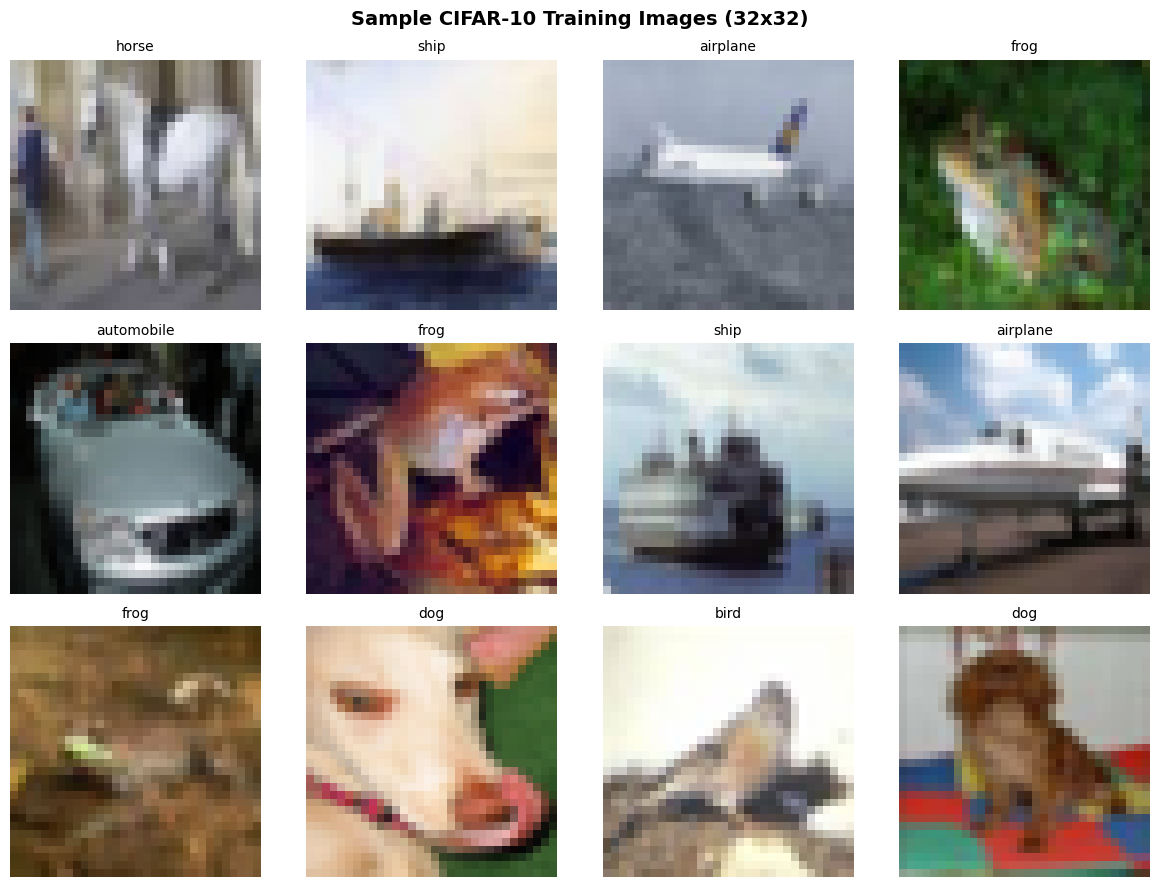

In [11]:
sample_df = labels_df.sample(12, random_state=42)
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
fig.suptitle('Sample CIFAR-10 Training Images (32x32)', fontsize=14, fontweight='bold')
for ax, (_, row) in zip(axes.flat, sample_df.iterrows()):
    image_id = str(row['id'])
    image    = Image.open(os.path.join(TRAIN_DIR, train_image_map[image_id])).convert('RGB')
    ax.imshow(image)
    ax.set_title(row['label'], fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Part 12 — Train/Validation Split (90/10, Stratified)

In [12]:
train_df, val_df = train_test_split(
    labels_df, test_size=0.10, random_state=SEED, stratify=labels_df['class_idx'])
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print(f'Training samples  : {len(train_df):,}')
print(f'Validation samples: {len(val_df):,}')

Training samples  : 45,000
Validation samples: 5,000


## Part 13 — Transforms for CNN from Scratch (keep 32x32)

In [13]:
CIFAR_MEAN = [0.4914, 0.4822, 0.4465]
CIFAR_STD  = [0.2470, 0.2435, 0.2616]

scratch_train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR_MEAN, std=CIFAR_STD)
])

scratch_val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR_MEAN, std=CIFAR_STD)
])
print('Scratch CNN transforms defined.')

Scratch CNN transforms defined.


## Part 14 — Create Datasets & DataLoaders

In [14]:
BATCH_SIZE = 128
scratch_train_dataset = CIFARLocalDataset(train_df, TRAIN_DIR, train_image_map, scratch_train_transform)
scratch_val_dataset   = CIFARLocalDataset(val_df,   TRAIN_DIR, train_image_map, scratch_val_transform)
train_loader = DataLoader(scratch_train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(scratch_val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f'Train dataset : {len(scratch_train_dataset):,} images')
print(f'Val   dataset : {len(scratch_val_dataset):,} images')
images, labels_batch = next(iter(train_loader))
print(f'Batch shape - images: {images.shape}  labels: {labels_batch.shape}')

Train dataset : 45,000 images
Val   dataset : 5,000 images
Batch shape - images: torch.Size([128, 3, 32, 32])  labels: torch.Size([128])


## Part 15 — Build CNN from Scratch

Architecture: `Input (3x32x32) -> [Conv->BN->ReLU->Conv->BN->ReLU->Pool->Dropout] x3 -> Flatten -> FC -> 10`

In [15]:
class ScratchCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 32x32 -> 16x16
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),
            # Block 2: 16x16 -> 8x8
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),
            # Block 3: 8x8 -> 4x4
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.3),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


scratch_model = ScratchCNN(num_classes=10).to(device)
print(scratch_model)
print(f'\nTrainable parameters: {count_parameters(scratch_model):,}')

ScratchCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.1, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

## Part 16 — Loss, Optimizer & Scheduler

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(scratch_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-5)
print('Criterion, optimizer, and scheduler ready.')

Criterion, optimizer, and scheduler ready.


## Part 17 — Training & Evaluation Helper Functions

In [17]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted  = torch.max(outputs, 1)
        total        += labels.size(0)
        correct      += (predicted == labels).sum().item()
    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            loss           = criterion(outputs, labels)
            running_loss  += loss.item() * images.size(0)
            _, predicted   = torch.max(outputs, 1)
            total         += labels.size(0)
            correct       += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return running_loss / total, correct / total, all_preds, all_labels

print('train_one_epoch and evaluate functions defined.')

train_one_epoch and evaluate functions defined.


## Part 18 — Train CNN from Scratch (30 Epochs)

> On CPU: ~15-30 min. On MPS/CUDA: ~5-8 min.

In [18]:
SCRATCH_EPOCHS   = 30
best_scratch_acc = 0.0
scratch_history  = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(SCRATCH_EPOCHS):
    train_loss, train_acc         = train_one_epoch(scratch_model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc, _, _     = evaluate(scratch_model, val_loader, criterion, device)
    scheduler.step()

    scratch_history['train_loss'].append(train_loss)
    scratch_history['val_loss'  ].append(val_loss)
    scratch_history['train_acc' ].append(train_acc)
    scratch_history['val_acc'   ].append(val_acc)

    if val_acc > best_scratch_acc:
        best_scratch_acc = val_acc
        torch.save(scratch_model.state_dict(), 'scratch_cnn_best.pth')

    best_flag = '  <- best' if val_acc == best_scratch_acc else ''
    print(f'Epoch [{epoch+1:02d}/{SCRATCH_EPOCHS}] | '
          f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc*100:.2f}% | '
          f'Val Loss: {val_loss:.4f}  Val Acc: {val_acc*100:.2f}%{best_flag}')

print(f'\nBest Scratch CNN Validation Accuracy: {best_scratch_acc*100:.2f}%')

Epoch [01/30] | Train Loss: 1.8065  Train Acc: 31.89% | Val Loss: 1.4088  Val Acc: 46.82%  <- best
Epoch [02/30] | Train Loss: 1.4795  Train Acc: 45.45% | Val Loss: 1.1290  Val Acc: 57.98%  <- best
Epoch [03/30] | Train Loss: 1.3065  Train Acc: 52.97% | Val Loss: 1.0251  Val Acc: 63.16%  <- best
Epoch [04/30] | Train Loss: 1.2062  Train Acc: 57.25% | Val Loss: 0.9248  Val Acc: 66.30%  <- best
Epoch [05/30] | Train Loss: 1.1156  Train Acc: 60.55% | Val Loss: 0.8681  Val Acc: 68.82%  <- best
Epoch [06/30] | Train Loss: 1.0560  Train Acc: 62.91% | Val Loss: 0.8037  Val Acc: 70.42%  <- best
Epoch [07/30] | Train Loss: 0.9961  Train Acc: 65.44% | Val Loss: 0.7820  Val Acc: 72.22%  <- best
Epoch [08/30] | Train Loss: 0.9450  Train Acc: 67.07% | Val Loss: 0.7221  Val Acc: 73.72%  <- best
Epoch [09/30] | Train Loss: 0.9034  Train Acc: 68.72% | Val Loss: 0.6671  Val Acc: 76.08%  <- best
Epoch [10/30] | Train Loss: 0.8613  Train Acc: 70.28% | Val Loss: 0.6450  Val Acc: 77.16%  <- best
Epoch [11/

## Part 19 — Load Best Scratch Checkpoint

In [19]:
scratch_model.load_state_dict(torch.load('scratch_cnn_best.pth', map_location=device))
scratch_model.eval()
print(f'Loaded best Scratch CNN - Validation Accuracy: {best_scratch_acc*100:.2f}%')

Loaded best Scratch CNN - Validation Accuracy: 84.84%


## Part 20 — Plot Scratch CNN Training Curves

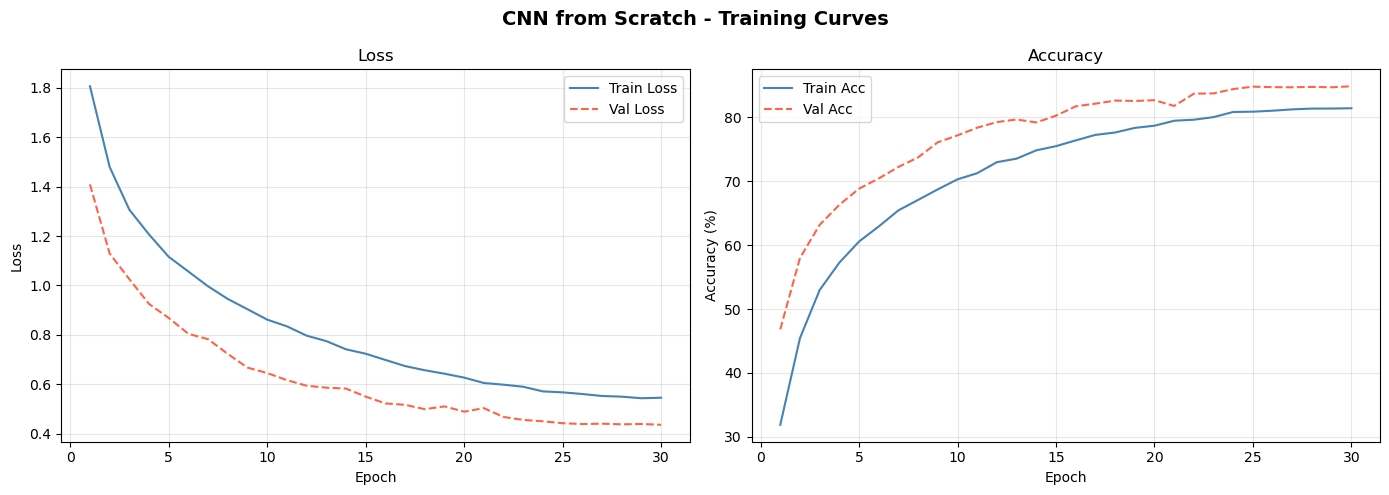

In [20]:
epochs_range = range(1, SCRATCH_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN from Scratch - Training Curves', fontsize=14, fontweight='bold')

axes[0].plot(epochs_range, scratch_history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(epochs_range, scratch_history['val_loss'],   label='Val Loss',   color='tomato', linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, np.array(scratch_history['train_acc'])*100, label='Train Acc', color='steelblue')
axes[1].plot(epochs_range, np.array(scratch_history['val_acc'])*100,   label='Val Acc',   color='tomato', linestyle='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Part 21 — Confusion Matrix & Classification Report (Scratch CNN)

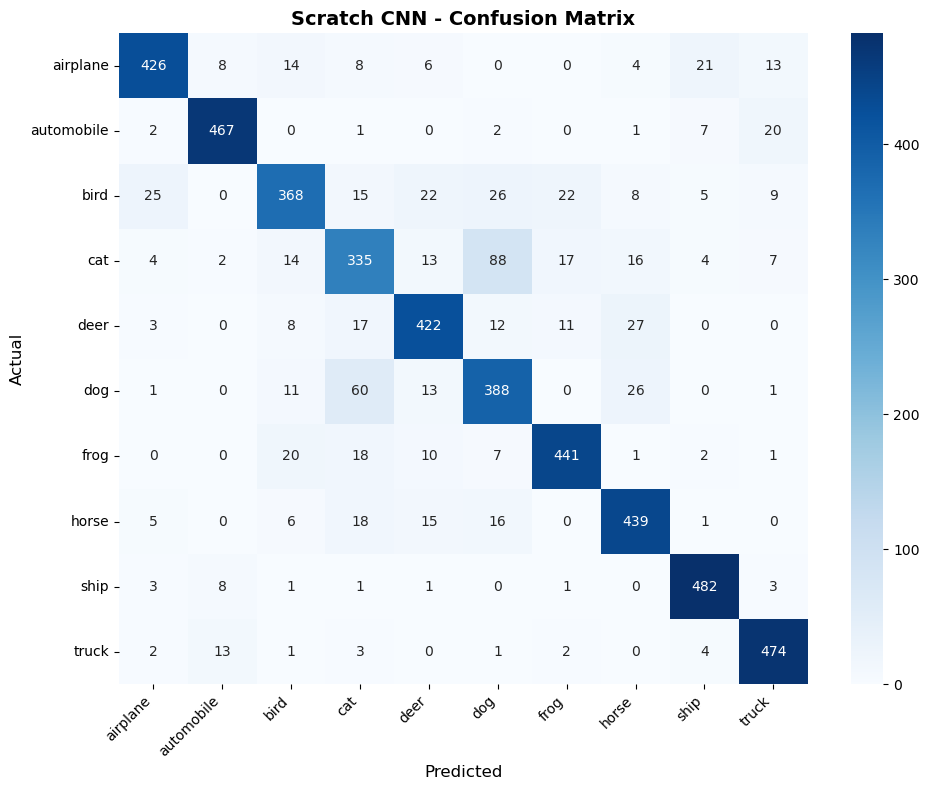


Classification Report (Scratch CNN):
              precision    recall  f1-score   support

    airplane       0.90      0.85      0.88       500
  automobile       0.94      0.93      0.94       500
        bird       0.83      0.74      0.78       500
         cat       0.70      0.67      0.69       500
        deer       0.84      0.84      0.84       500
         dog       0.72      0.78      0.75       500
        frog       0.89      0.88      0.89       500
       horse       0.84      0.88      0.86       500
        ship       0.92      0.96      0.94       500
       truck       0.90      0.95      0.92       500

    accuracy                           0.85      5000
   macro avg       0.85      0.85      0.85      5000
weighted avg       0.85      0.85      0.85      5000



In [21]:
_, _, scratch_preds, scratch_true = evaluate(scratch_model, val_loader, criterion, device)
cm = confusion_matrix(scratch_true, scratch_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted', fontsize=12); ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Scratch CNN - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
print('\nClassification Report (Scratch CNN):')
print(classification_report(scratch_true, scratch_preds, target_names=class_names))

## Part 22 — Visualize Conv Filters (Layer 1)

The first Conv layer learns low-level patterns: **edges, colour blobs, textures**.

Filter weight tensor shape: torch.Size([32, 3, 3, 3])


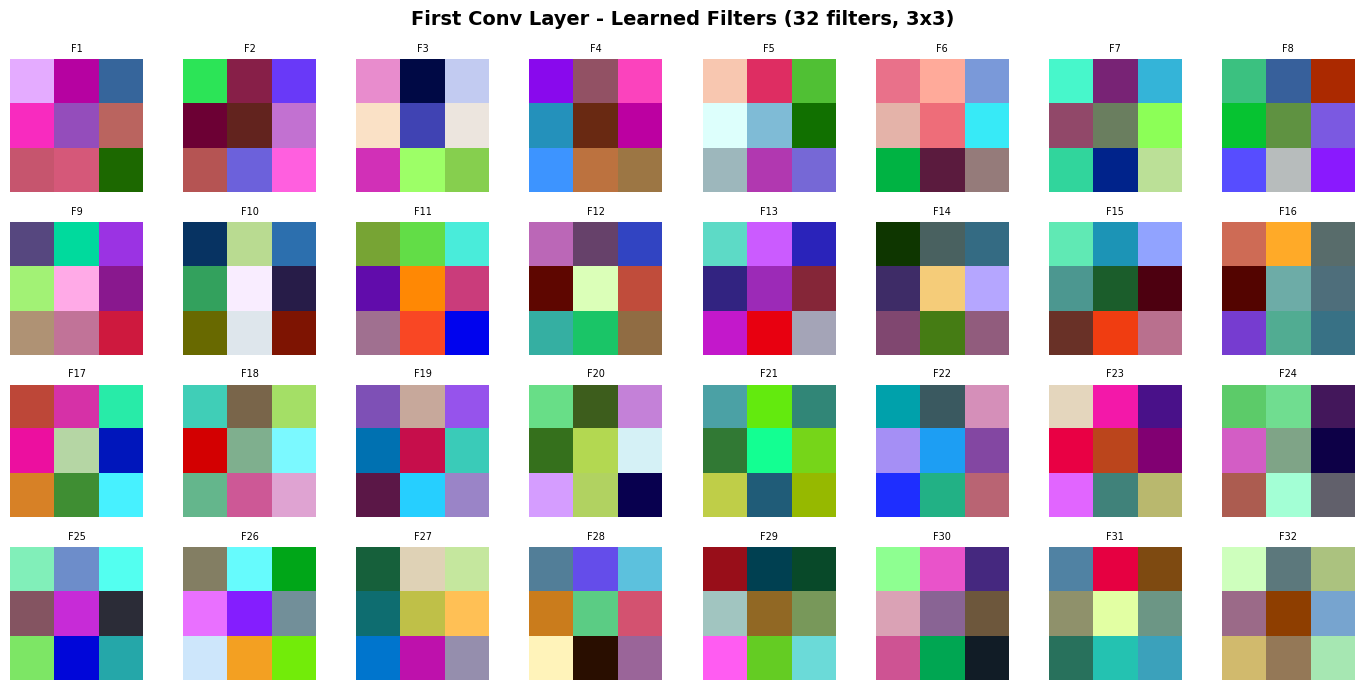

In [22]:
first_conv = scratch_model.features[0]
weights    = first_conv.weight.data.cpu()
print('Filter weight tensor shape:', weights.shape)  # [32, 3, 3, 3]

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
fig.suptitle('First Conv Layer - Learned Filters (32 filters, 3x3)',
             fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    f = weights[i].clone()
    f = f - f.min()
    f = f / (f.max() + 1e-8)
    f = f.permute(1, 2, 0)
    ax.imshow(f.numpy())
    ax.set_title(f'F{i+1}', fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Part 23 — Visualize Feature Map Activations (After First Conv)

See **what the CNN actually responds to** for a real CIFAR-10 image.

Input tensor shape: torch.Size([1, 3, 32, 32])
True class: horse
Feature map shape: torch.Size([32, 32, 32])


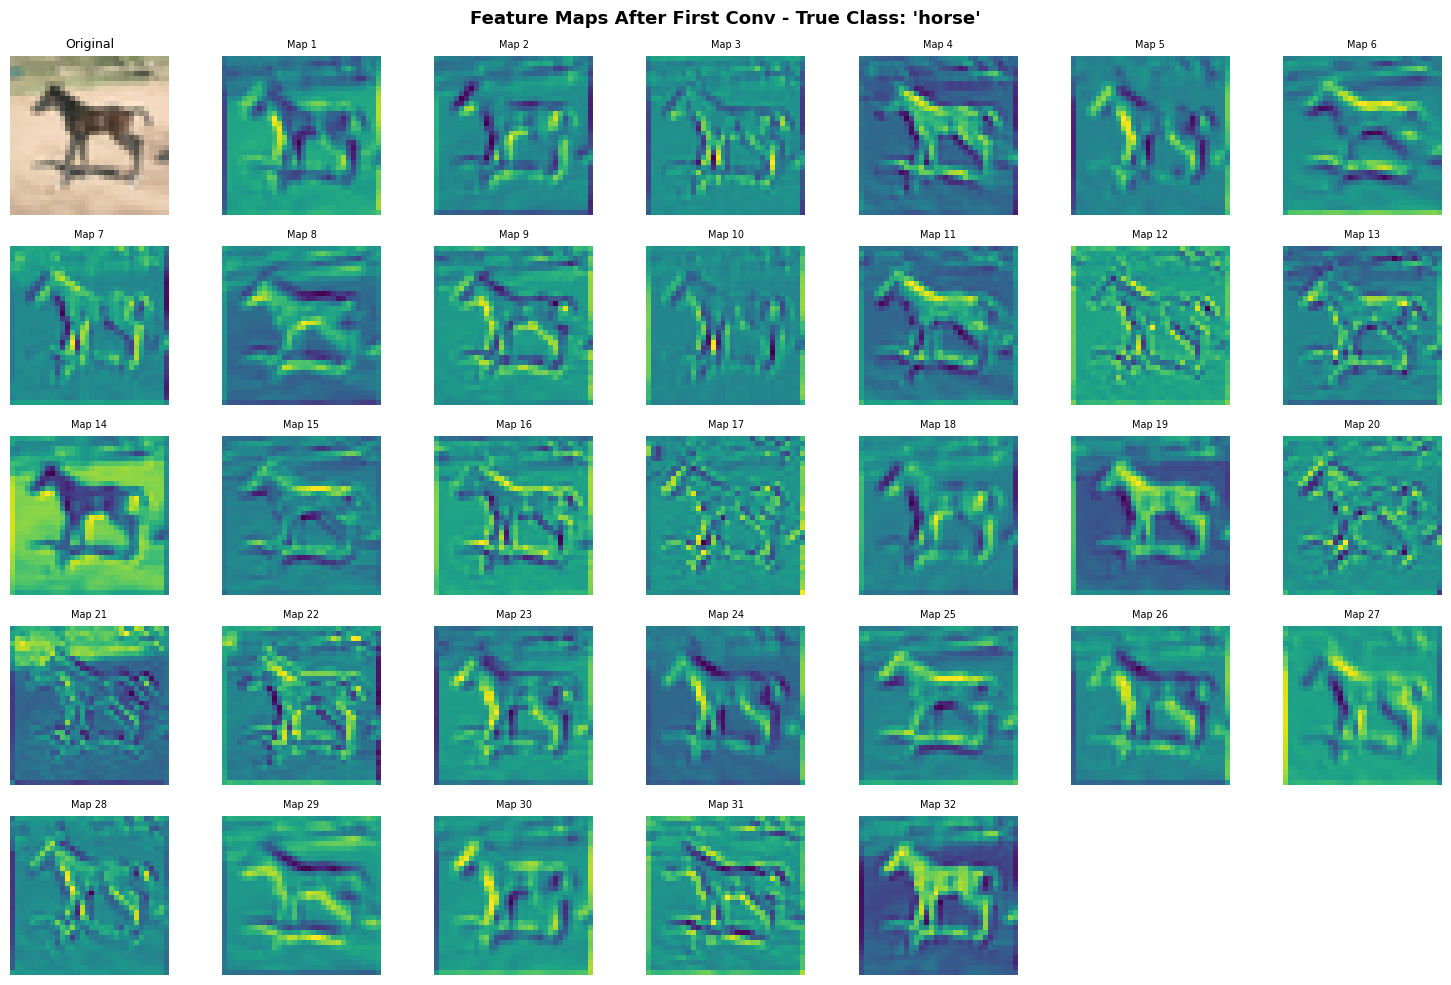

In [23]:
sample_image, sample_label = scratch_val_dataset[0]
input_tensor = sample_image.unsqueeze(0).to(device)
print('Input tensor shape:', input_tensor.shape)
print('True class:', class_names[sample_label])

scratch_model.eval()
with torch.no_grad():
    act_after_conv1 = scratch_model.features[0](input_tensor)
act_maps = act_after_conv1.squeeze(0).cpu()
print('Feature map shape:', act_maps.shape)

fig = plt.figure(figsize=(15, 10))
fig.suptitle(f"Feature Maps After First Conv - True Class: '{class_names[sample_label]}'",
             fontsize=13, fontweight='bold')

# Show original image
ax0 = fig.add_subplot(5, 7, 1)
orig = sample_image.clone()
for c, (m, s) in enumerate(zip(CIFAR_MEAN, CIFAR_STD)):
    orig[c] = orig[c] * s + m
orig = orig.permute(1, 2, 0).numpy().clip(0, 1)
ax0.imshow(orig); ax0.set_title('Original', fontsize=9); ax0.axis('off')

for i in range(32):
    ax = fig.add_subplot(5, 7, i + 2)
    ax.imshow(act_maps[i].numpy(), cmap='viridis')
    ax.set_title(f'Map {i+1}', fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Part 24 — Visualize Deeper Activations (Average Maps Across All 3 Blocks)

Shows how features evolve from low-level edges -> high-level semantics.

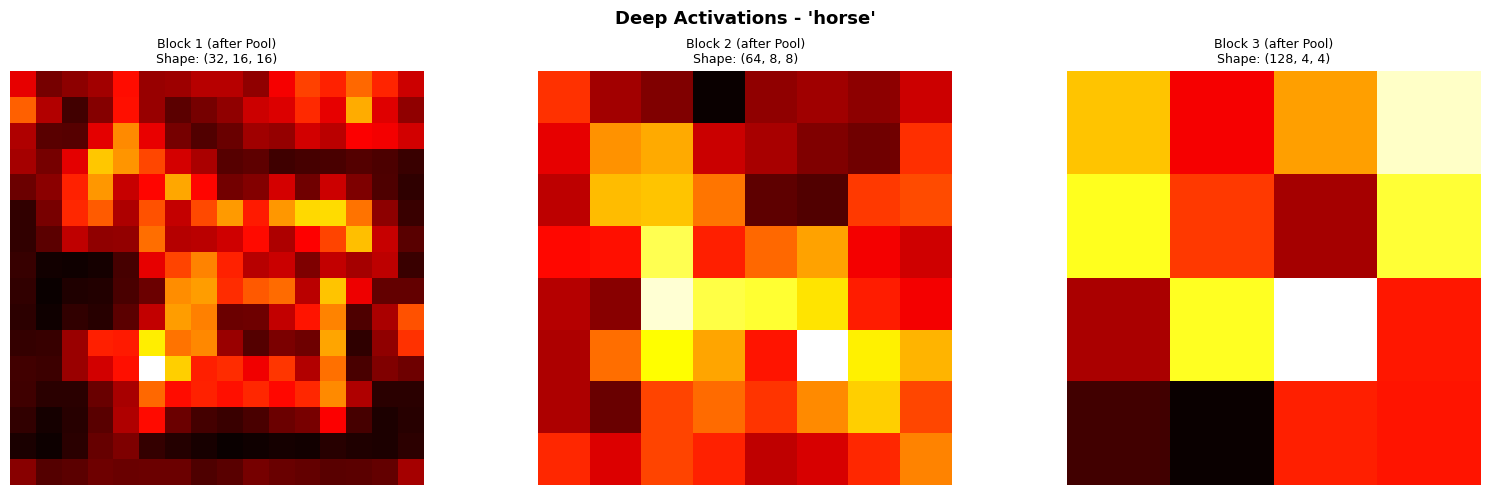

In [24]:
scratch_model.eval()
# Indices correspond to MaxPool2d layers (end of each block)
block_end_indices = {'Block 1 (after Pool)': 6, 'Block 2 (after Pool)': 14, 'Block 3 (after Pool)': 22}

fig, big_axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"Deep Activations - '{class_names[sample_label]}'", fontsize=13, fontweight='bold')

for ax, (block_name, layer_idx) in zip(big_axes, block_end_indices.items()):
    with torch.no_grad():
        act = input_tensor.clone()
        for i in range(layer_idx + 1):
            act = scratch_model.features[i](act)
    maps    = act.squeeze(0).cpu()
    avg_map = maps.mean(0).numpy()
    ax.imshow(avg_map, cmap='hot')
    ax.set_title(f'{block_name}\nShape: {tuple(maps.shape)}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Part 25 — ResNet-18 Transfer Learning

Resize 32x32 -> 224x224 (ImageNet expected input size).

In [25]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

resnet_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

resnet_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])
print('ResNet-18 transforms defined (32x32 -> 224x224).')

ResNet-18 transforms defined (32x32 -> 224x224).


In [26]:
resnet_train_dataset = CIFARLocalDataset(train_df, TRAIN_DIR, train_image_map, resnet_train_transform)
resnet_val_dataset   = CIFARLocalDataset(val_df,   TRAIN_DIR, train_image_map, resnet_val_transform)

resnet_train_loader = DataLoader(resnet_train_dataset, batch_size=64, shuffle=True,  num_workers=0)
resnet_val_loader   = DataLoader(resnet_val_dataset,   batch_size=64, shuffle=False, num_workers=0)
print(f'ResNet Train: {len(resnet_train_dataset):,}  Val: {len(resnet_val_dataset):,}')

ResNet Train: 45,000  Val: 5,000


## Part 26 — Load Pretrained ResNet-18 & Replace Classifier

> First run downloads ~45 MB of pretrained ImageNet weights.

In [27]:
resnet_model = resnet18(weights=ResNet18_Weights.DEFAULT)
num_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_features, 10)
resnet_model    = resnet_model.to(device)
print('New classifier head:', resnet_model.fc)
print(f'Total trainable parameters: {count_parameters(resnet_model):,}')

New classifier head: Linear(in_features=512, out_features=10, bias=True)
Total trainable parameters: 11,181,642


## Part 27 — Stage 1: Feature Extraction (Freeze backbone, train FC only)

In [28]:
for param in resnet_model.parameters():
    param.requires_grad = False
for param in resnet_model.fc.parameters():
    param.requires_grad = True

print(f'Stage 1 - Trainable parameters: {count_parameters(resnet_model):,}  (FC only)')

resnet_criterion = nn.CrossEntropyLoss()
resnet_optimizer = optim.Adam(resnet_model.fc.parameters(), lr=0.001)

Stage 1 - Trainable parameters: 5,130  (FC only)


In [29]:
STAGE1_EPOCHS   = 10
best_resnet_acc = 0.0
resnet_history  = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(STAGE1_EPOCHS):
    train_loss, train_acc         = train_one_epoch(resnet_model, resnet_train_loader, resnet_criterion, resnet_optimizer, device)
    val_loss,   val_acc, _, _     = evaluate(resnet_model, resnet_val_loader, resnet_criterion, device)

    resnet_history['train_loss'].append(train_loss)
    resnet_history['val_loss'  ].append(val_loss)
    resnet_history['train_acc' ].append(train_acc)
    resnet_history['val_acc'   ].append(val_acc)

    if val_acc > best_resnet_acc:
        best_resnet_acc = val_acc
        torch.save(resnet_model.state_dict(), 'resnet18_transfer_best.pth')

    best_flag = '  <- best' if val_acc == best_resnet_acc else ''
    print(f'[Stage1] Epoch [{epoch+1:02d}/{STAGE1_EPOCHS}] | '
          f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc*100:.2f}% | '
          f'Val Loss: {val_loss:.4f}  Val Acc: {val_acc*100:.2f}%{best_flag}')

print(f'\nBest ResNet-18 (Stage 1) Val Accuracy: {best_resnet_acc*100:.2f}%')

[Stage1] Epoch [01/10] | Train Loss: 1.0062  Train Acc: 67.42% | Val Loss: 0.6321  Val Acc: 78.98%  <- best
[Stage1] Epoch [02/10] | Train Loss: 0.7542  Train Acc: 74.14% | Val Loss: 0.5947  Val Acc: 79.84%  <- best
[Stage1] Epoch [03/10] | Train Loss: 0.7138  Train Acc: 75.25% | Val Loss: 0.5729  Val Acc: 80.76%  <- best
[Stage1] Epoch [04/10] | Train Loss: 0.7016  Train Acc: 75.80% | Val Loss: 0.5693  Val Acc: 80.80%  <- best
[Stage1] Epoch [05/10] | Train Loss: 0.6903  Train Acc: 76.11% | Val Loss: 0.5441  Val Acc: 81.42%  <- best
[Stage1] Epoch [06/10] | Train Loss: 0.6861  Train Acc: 76.36% | Val Loss: 0.5850  Val Acc: 80.04%
[Stage1] Epoch [07/10] | Train Loss: 0.6817  Train Acc: 76.49% | Val Loss: 0.5421  Val Acc: 81.48%  <- best
[Stage1] Epoch [08/10] | Train Loss: 0.6745  Train Acc: 76.75% | Val Loss: 0.5391  Val Acc: 81.30%
[Stage1] Epoch [09/10] | Train Loss: 0.6719  Train Acc: 76.75% | Val Loss: 0.5557  Val Acc: 81.04%
[Stage1] Epoch [10/10] | Train Loss: 0.6689  Train Acc:

## Part 28 — Stage 2: Fine-Tuning (Unfreeze layer4 + FC)

In [30]:
resnet_model.load_state_dict(torch.load('resnet18_transfer_best.pth', map_location=device))

for param in resnet_model.parameters():
    param.requires_grad = False
for param in resnet_model.layer4.parameters():
    param.requires_grad = True
for param in resnet_model.fc.parameters():
    param.requires_grad = True

print(f'Stage 2 - Trainable parameters: {count_parameters(resnet_model):,}  (layer4 + FC)')

fine_tune_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, resnet_model.parameters()), lr=1e-4, weight_decay=1e-4)

Stage 2 - Trainable parameters: 8,398,858  (layer4 + FC)


In [31]:
STAGE2_EPOCHS      = 10
best_finetuned_acc = best_resnet_acc
finetune_history   = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(STAGE2_EPOCHS):
    train_loss, train_acc     = train_one_epoch(resnet_model, resnet_train_loader, resnet_criterion, fine_tune_optimizer, device)
    val_loss,   val_acc, _, _ = evaluate(resnet_model, resnet_val_loader, resnet_criterion, device)

    finetune_history['train_loss'].append(train_loss)
    finetune_history['val_loss'  ].append(val_loss)
    finetune_history['train_acc' ].append(train_acc)
    finetune_history['val_acc'   ].append(val_acc)

    if val_acc > best_finetuned_acc:
        best_finetuned_acc = val_acc
        torch.save(resnet_model.state_dict(), 'resnet18_finetuned_best.pth')

    best_flag = '  <- best' if val_acc == best_finetuned_acc else ''
    print(f'[Stage2] Epoch [{epoch+1:02d}/{STAGE2_EPOCHS}] | '
          f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc*100:.2f}% | '
          f'Val Loss: {val_loss:.4f}  Val Acc: {val_acc*100:.2f}%{best_flag}')

print(f'\nBest Fine-Tuned ResNet-18 Accuracy: {best_finetuned_acc*100:.2f}%')

[Stage2] Epoch [01/10] | Train Loss: 0.4373  Train Acc: 84.99% | Val Loss: 0.2785  Val Acc: 90.82%  <- best
[Stage2] Epoch [02/10] | Train Loss: 0.2796  Train Acc: 90.39% | Val Loss: 0.2223  Val Acc: 92.50%  <- best
[Stage2] Epoch [03/10] | Train Loss: 0.2138  Train Acc: 92.52% | Val Loss: 0.2404  Val Acc: 92.10%
[Stage2] Epoch [04/10] | Train Loss: 0.1801  Train Acc: 93.72% | Val Loss: 0.2040  Val Acc: 93.28%  <- best
[Stage2] Epoch [05/10] | Train Loss: 0.1473  Train Acc: 94.73% | Val Loss: 0.2183  Val Acc: 93.08%
[Stage2] Epoch [06/10] | Train Loss: 0.1298  Train Acc: 95.47% | Val Loss: 0.2248  Val Acc: 92.94%
[Stage2] Epoch [07/10] | Train Loss: 0.1113  Train Acc: 96.14% | Val Loss: 0.2360  Val Acc: 92.92%
[Stage2] Epoch [08/10] | Train Loss: 0.0922  Train Acc: 96.73% | Val Loss: 0.2394  Val Acc: 93.34%  <- best
[Stage2] Epoch [09/10] | Train Loss: 0.0907  Train Acc: 96.83% | Val Loss: 0.2095  Val Acc: 93.78%  <- best
[Stage2] Epoch [10/10] | Train Loss: 0.0785  Train Acc: 97.20% |

## Part 29 — Load Best Fine-Tuned Checkpoint

In [32]:
best_ckpt = 'resnet18_finetuned_best.pth' if os.path.exists('resnet18_finetuned_best.pth') \
            else 'resnet18_transfer_best.pth'
resnet_model.load_state_dict(torch.load(best_ckpt, map_location=device))
resnet_model.eval()
print(f'Loaded: {best_ckpt}')
print(f'Best ResNet-18 Validation Accuracy: {best_finetuned_acc*100:.2f}%')

Loaded: resnet18_finetuned_best.pth
Best ResNet-18 Validation Accuracy: 93.78%


## Part 30 — ResNet-18 Confusion Matrix & Classification Report

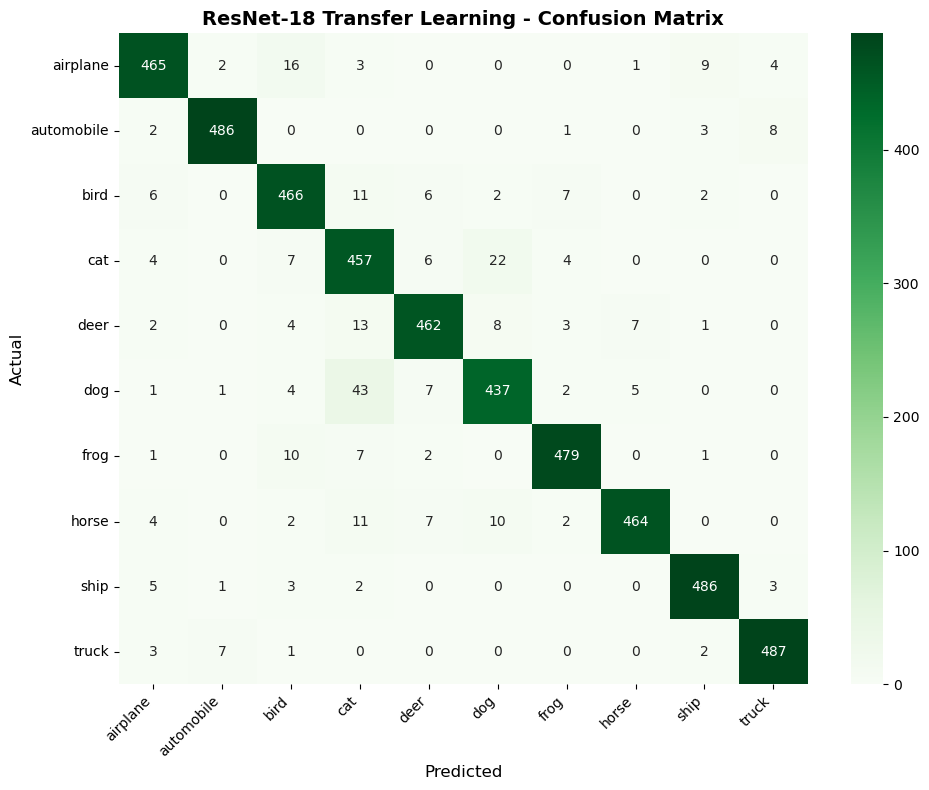


Classification Report (ResNet-18):
              precision    recall  f1-score   support

    airplane       0.94      0.93      0.94       500
  automobile       0.98      0.97      0.97       500
        bird       0.91      0.93      0.92       500
         cat       0.84      0.91      0.87       500
        deer       0.94      0.92      0.93       500
         dog       0.91      0.87      0.89       500
        frog       0.96      0.96      0.96       500
       horse       0.97      0.93      0.95       500
        ship       0.96      0.97      0.97       500
       truck       0.97      0.97      0.97       500

    accuracy                           0.94      5000
   macro avg       0.94      0.94      0.94      5000
weighted avg       0.94      0.94      0.94      5000



In [33]:
_, _, resnet_preds, resnet_true = evaluate(resnet_model, resnet_val_loader, resnet_criterion, device)
cm_resnet = confusion_matrix(resnet_true, resnet_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted', fontsize=12); ax.set_ylabel('Actual', fontsize=12)
ax.set_title('ResNet-18 Transfer Learning - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
print('\nClassification Report (ResNet-18):')
print(classification_report(resnet_true, resnet_preds, target_names=class_names))

## Part 31 — Final Accuracy Comparison: Scratch CNN vs ResNet-18

In [34]:
comparison = pd.DataFrame({
    'Model': ['CNN from Scratch', 'ResNet-18 (Feature Extraction)', 'ResNet-18 (Fine-Tuned)'],
    'Validation Accuracy (%)': [
        round(best_scratch_acc   * 100, 2),
        round(best_resnet_acc    * 100, 2),
        round(best_finetuned_acc * 100, 2)
    ]
})
display(comparison)

,Model,Validation Accuracy (%)
0,CNN from Scratch,84.84
1,ResNet-18 (Feature Extraction),81.48
2,ResNet-18 (Fine-Tuned),93.78


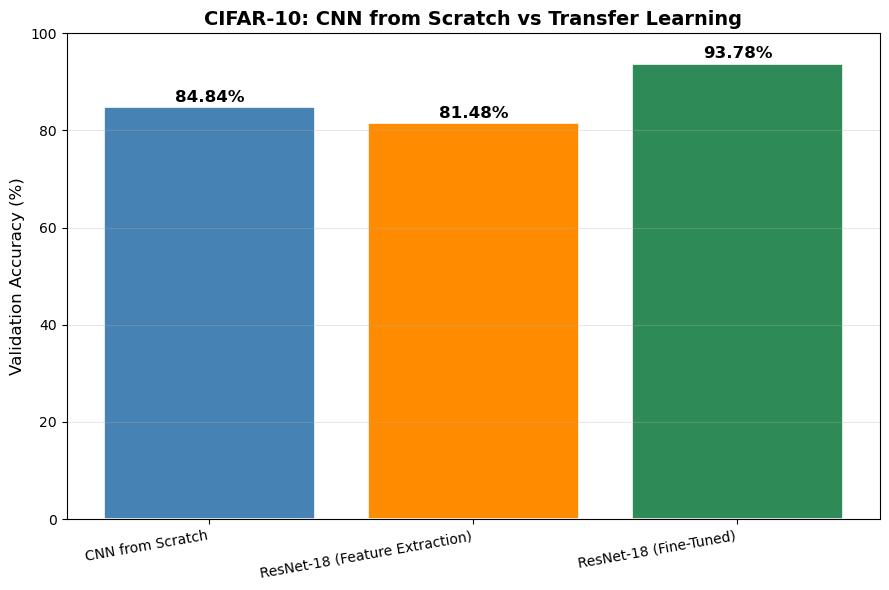

In [35]:
colors = ['steelblue', 'darkorange', 'seagreen']
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(comparison['Model'], comparison['Validation Accuracy (%)'],
              color=colors, edgecolor='white', linewidth=1.2)
for bar, acc in zip(bars, comparison['Validation Accuracy (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax.set_title('CIFAR-10: CNN from Scratch vs Transfer Learning', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100); ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=10, ha='right'); plt.tight_layout(); plt.show()

## Part 32 — Validation Accuracy Curves: Scratch vs Transfer Learning

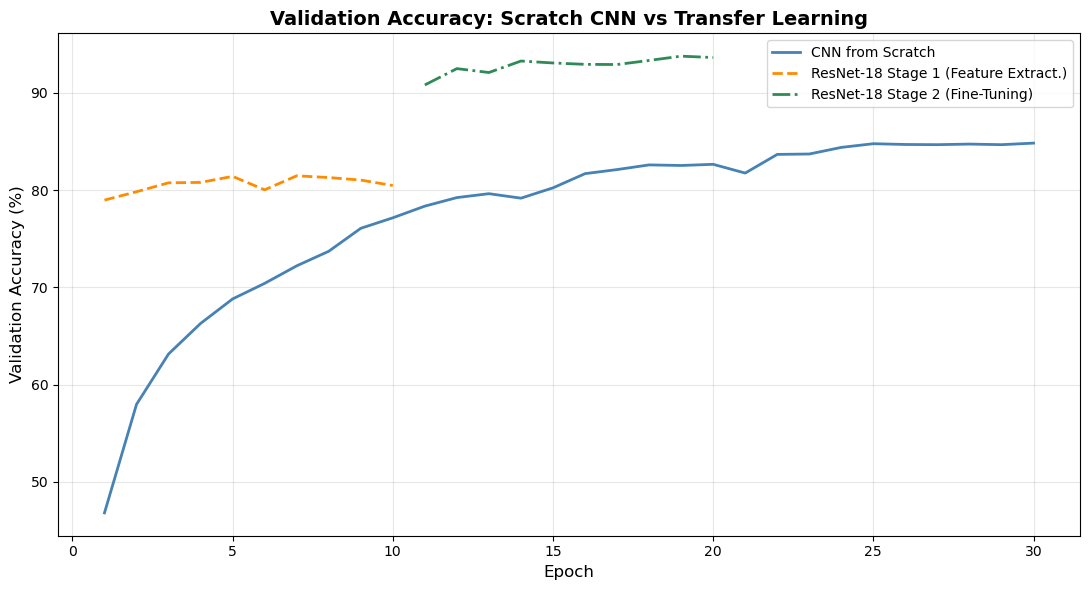

In [36]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(range(1, SCRATCH_EPOCHS+1), np.array(scratch_history['val_acc'])*100,
        label='CNN from Scratch', color='steelblue', linewidth=2)

ax.plot(range(1, STAGE1_EPOCHS+1), np.array(resnet_history['val_acc'])*100,
        label='ResNet-18 Stage 1 (Feature Extract.)', color='darkorange', linewidth=2, linestyle='--')

ax.plot(range(STAGE1_EPOCHS+1, STAGE1_EPOCHS+STAGE2_EPOCHS+1), np.array(finetune_history['val_acc'])*100,
        label='ResNet-18 Stage 2 (Fine-Tuning)', color='seagreen', linewidth=2, linestyle='-.')

ax.set_xlabel('Epoch', fontsize=12); ax.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax.set_title('Validation Accuracy: Scratch CNN vs Transfer Learning', fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Part 33 — Predict a Single Validation Image (Both Models)

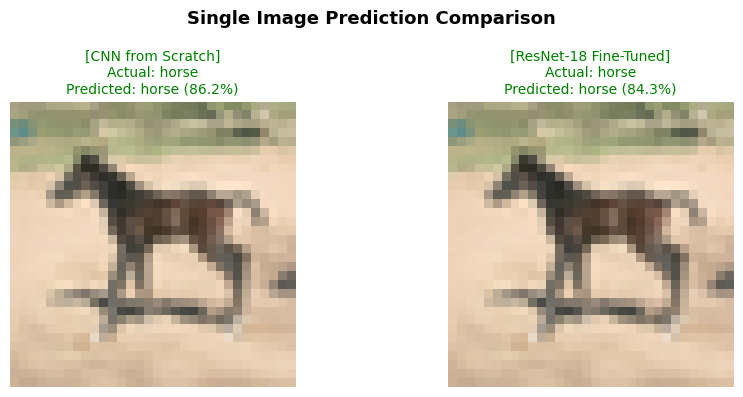

In [37]:
def predict_image(model, image_path, transform, class_names, device):
    image  = Image.open(image_path).convert('RGB')
    tensor = transform(image).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        outputs  = model(tensor)
        probs    = torch.softmax(outputs, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
    return class_names[pred_idx], probs[0, pred_idx].item(), image

sample_id       = val_df.iloc[0]['id']
sample_filename = train_image_map[str(sample_id)]
sample_path     = os.path.join(TRAIN_DIR, sample_filename)
actual_label    = val_df.iloc[0]['label']

pred_scratch, conf_scratch, img = predict_image(scratch_model, sample_path, scratch_val_transform, class_names, device)
pred_resnet,  conf_resnet,  _   = predict_image(resnet_model,  sample_path, resnet_val_transform,  class_names, device)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (title, pred, conf) in zip(axes, [
        ('CNN from Scratch',     pred_scratch, conf_scratch),
        ('ResNet-18 Fine-Tuned', pred_resnet,  conf_resnet)
    ]):
    ax.imshow(img)
    color = 'green' if pred == actual_label else 'red'
    ax.set_title(f'[{title}]\nActual: {actual_label}\nPredicted: {pred} ({conf*100:.1f}%)',
                 color=color, fontsize=10)
    ax.axis('off')
plt.suptitle('Single Image Prediction Comparison', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## Part 34 — Generate Predictions for Unlabeled Test Folder

In [38]:
test_image_map = {}
for filename in os.listdir(TEST_DIR):
    filepath = os.path.join(TEST_DIR, filename)
    if os.path.isfile(filepath):
        stem = os.path.splitext(filename)[0]
        test_image_map[str(stem)] = filename
print(f'Test images found: {len(test_image_map):,}')

Test images found: 300,000


In [39]:
resnet_model.eval()
test_results = []

for image_id, filename in test_image_map.items():
    image_path = os.path.join(TEST_DIR, filename)
    image      = Image.open(image_path).convert('RGB')
    tensor     = resnet_val_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output     = resnet_model(tensor)
        probs      = torch.softmax(output, dim=1)
        pred_idx   = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred_idx].item()
    test_results.append({'id': image_id, 'label': class_names[pred_idx], 'confidence': round(confidence, 4)})

test_predictions_df = pd.DataFrame(test_results)
try:
    test_predictions_df['id'] = test_predictions_df['id'].astype(int)
    test_predictions_df       = test_predictions_df.sort_values('id').reset_index(drop=True)
except:
    pass

display(test_predictions_df.head(10))
print(f'Total predictions: {len(test_predictions_df):,}')

,id,label,confidence
0,1,deer,0.4009
1,2,airplane,0.4719
2,3,automobile,0.9997
3,4,ship,1.0000
4,5,airplane,0.9970
5,6,cat,1.0000
6,7,airplane,1.0000
7,8,cat,0.9996
8,9,bird,0.4826
9,10,deer,0.5415


Total predictions: 300,000


In [40]:
output_csv = os.path.join(DATA_DIR, 'cifar10_test_predictions.csv')
test_predictions_df.to_csv(output_csv, index=False)
print(f'Predictions saved to: {output_csv}')

Predictions saved to: Cifar-10/cifar10_test_predictions.csv


## Part 35 — Visualize Sample Test Predictions

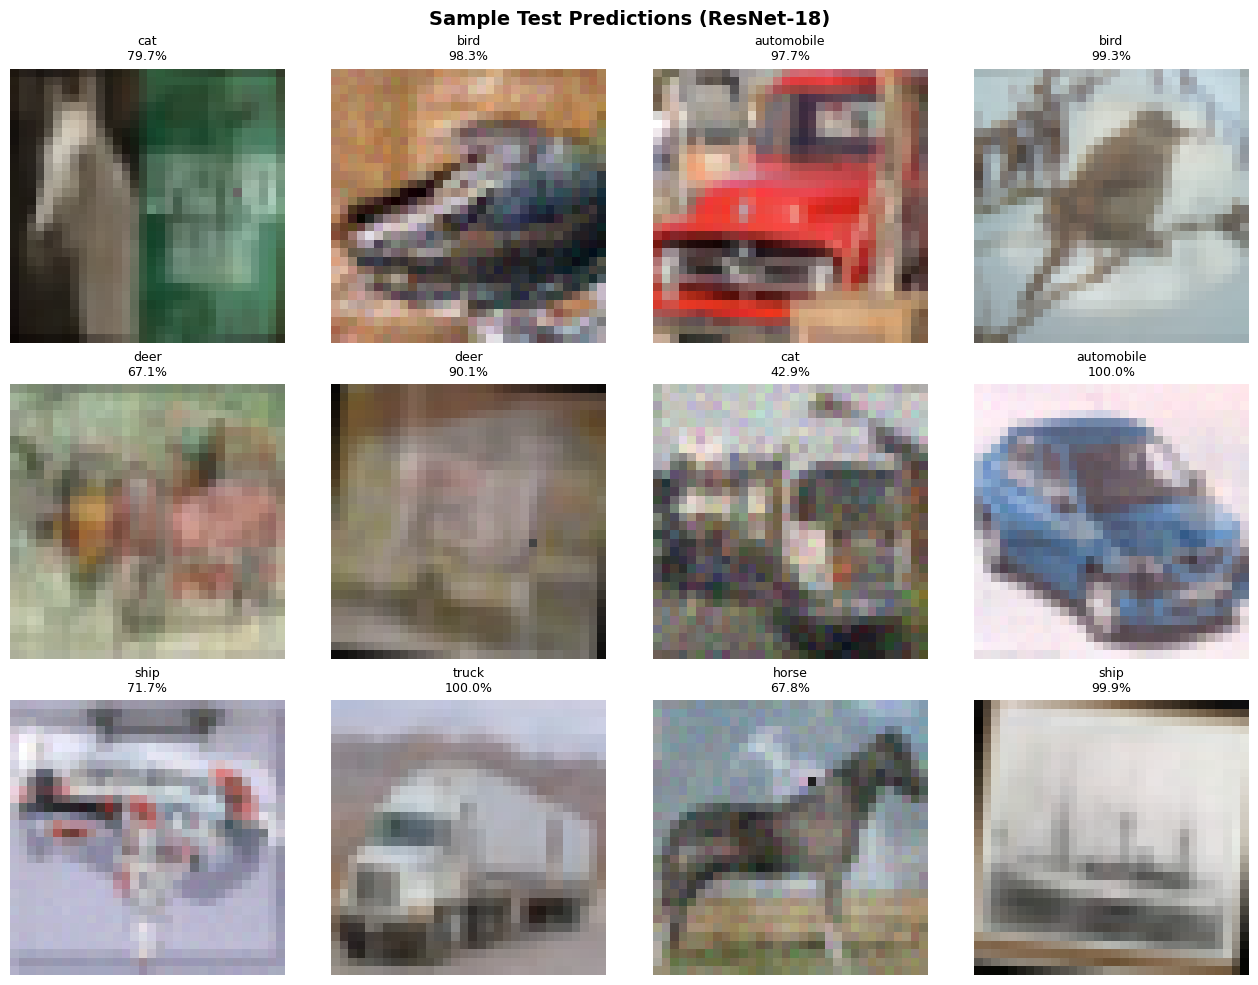

In [41]:
sample_test = test_predictions_df.sample(min(12, len(test_predictions_df)), random_state=42)
fig, axes   = plt.subplots(3, 4, figsize=(13, 10))
fig.suptitle('Sample Test Predictions (ResNet-18)', fontsize=14, fontweight='bold')
for ax, (_, row) in zip(axes.flat, sample_test.iterrows()):
    filename   = test_image_map[str(row['id'])]
    image_path = os.path.join(TEST_DIR, filename)
    image      = Image.open(image_path).convert('RGB')
    ax.imshow(image)
    ax.set_title(f"{row['label']}\n{row['confidence']*100:.1f}%", fontsize=9)
    ax.axis('off')
plt.tight_layout(); plt.show()

## Part 36 — Why ResNet Works: Residual Connections

Standard deep networks suffer from **vanishing gradients**.

ResNet introduces **skip connections** (residual learning):

```
Instead of learning:  H(x)
ResNet learns:        F(x) = H(x) - x
Output becomes:       H(x) = F(x) + x   <- skip connection
```

This lets gradients flow **directly backwards**, enabling networks of 18, 34, 50, 101, 152 layers.

## Part 37 — CNN Limitations: Motivation for RNNs & Transformers

### What CNNs Are Good At

| Task | Input | CNN Works? |
|---|---|---|
| Image classification | Fixed-size grid | YES |
| Object detection | Fixed-size image | YES |
| Image segmentation | Spatial pixels | YES |

### Where CNNs Fail

**Problem 1 — Variable-length sequences**  
Sentences have different lengths. CNNs require fixed-size inputs.

**Problem 2 — Long-range dependencies**  
> "The trophy didn't fit in the suitcase because **it** was too big."

What does 'it' refer to? The answer requires understanding words far apart.  
A CNN's local receptive field sees only a small neighbourhood at each layer.

**Problem 3 — Sequential / temporal data**  
Time-series: `price[t]` may depend on `price[t-100]`.  
CNNs have no notion of temporal order or memory state.

---

### The Full Deep Learning Roadmap

```
ANN      -> tabular / fixed features
  |
CNN      -> spatial hierarchies (images)
  |        LIMITATION: fixed grids, no sequential memory
RNN      -> sequences step-by-step, hidden state
  |        LIMITATION: vanishing gradients over long sequences
LSTM/GRU -> gating for long-term memory
  |        LIMITATION: sequential - slow to train
Transformer -> self-attention: all positions simultaneously
               BERT / GPT / LLaMA / ViT / AlphaFold
```

## Experiment Complete

| Model | Validation Accuracy |
|---|---|
| CNN from Scratch | Run cell above for your number |
| ResNet-18 (Feature Extraction) | Run cell above |
| ResNet-18 (Fine-Tuned) | Run cell above |

**Files saved during training:**
- `scratch_cnn_best.pth`
- `resnet18_transfer_best.pth`
- `resnet18_finetuned_best.pth`
- `cifar-10/cifar10_test_predictions.csv`